# **Dự Án Nghiên Cứu & Dự Đoán Khả Năng Chi Trả Nhà Ở Toàn Cầu (1975–2025)**
Thực hiện bởi: Võ Bạch Kim Thịnh.
1. Tổng quan bài toán
Khả năng chi trả nhà ở (Housing Affordability) là một trong những chỉ số vĩ mô quan trọng phản ánh sức khỏe kinh tế và an sinh xã hội của một quốc gia.
Dự án này tập trung phân tích xu hướng biến động và xây dựng mô hình học máy dự đoán Chỉ số chi trả nhà ở dựa trên chuỗi dữ liệu lịch sử kéo dài 50 năm (1975–2025) của 26 quốc gia và 2 nhóm tổng hợp toàn cầu.

2. Đặc điểm tập dữ liệu
* Mốc chuẩn hóa: Toàn bộ dữ liệu được điều chỉnh quy đổi về mốc gốc $2024 = 100$.Đơn vị phân tích: Quốc gia - Năm (Country-Year).
* Mục tiêu: Xây dựng mô hình hồi quy (Regression) dự đoán chỉ số chi trả, kết hợp đánh giá phân khúc phân loại (Classification) để kiểm soát rủi ro Overfitting trên dữ liệu thời gian.
3. Mục lục Notebook (Table of Contents)
* Khởi tạo môi trường & Tải dữ liệu
* Khám phá & Kiểm tra chất lượng dữ liệu sơ bộ
* Trực quan hóa dữ liệu đỉnh cao (EDA với 8 biểu đồ chuyên sâu)
* Tiền xử lý dữ liệu & Chia tách chuỗi thời gian (Time-based split)
* Huấn luyện mô hình học máy (Ridge Baseline vs. Tree-based Models)
* Đánh giá nâng cao (Regression Metrics & Confusion Matrix)

In [9]:
import os
import sys
import warnings
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Ecosystem for Preprocessing, Modeling, and Evaluation
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, classification_report

# Suppress warnings to maintain clean production execution logs
warnings.filterwarnings('ignore')

# Establish professional graphics parameters
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.figsize': (12, 6)
})

# Universal random state seed for absolute reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("[-] Production environment initialized successfully. Random seeds locked.")

[-] Production environment initialized successfully. Random seeds locked.


In [10]:
def load_housing_affordability_dataset():
    """
    Attempts to read data from the designated Google Drive directory path.
    If the path is unreachable, gracefully falls back to the current local working directory.
    """
    primary_drive_path = "/content/drive/MyDrive/Data/accessibilit-economica-alloggi-26-paesi-1975-2025.csv"
    local_fallback_name = "accessibilit-economica-alloggi-26-paesi-1975-2025.csv"

    # Check if Google Drive file is accessible
    if os.path.exists(primary_drive_path):
        print(f"[-] Successfully located dataset at primary Drive location: {primary_drive_path}")
        return pd.read_csv(primary_drive_path)

    # Check local workspace fallback
    elif os.path.exists(local_fallback_name):
        print(f"[*] Drive path not found. Accessing fallback local file: {os.getcwd()}/{local_fallback_name}")
        return pd.read_csv(local_fallback_name)

    else:
        # Raise clear instructional error if no file can be found
        raise FileNotFoundError(
            f"Dataset not located! Please ensure the file is uploaded to either:\n"
            f"1. Primary Path: {primary_drive_path}\n"
            f"2. Local Root Directory: {os.getcwd()}/{local_fallback_name}"
        )

# Execute the ingestion function
df = load_housing_affordability_dataset()

# Print shapes and initial rows
print(f"\n[-] Ingestion successful. Data dimensions: {df.shape[0]} rows, {df.shape[1]} columns.")
print("[-] Displaying the first 5 records (.head()):")
display(df.head())

[-] Successfully located dataset at primary Drive location: /content/drive/MyDrive/Data/accessibilit-economica-alloggi-26-paesi-1975-2025.csv

[-] Ingestion successful. Data dimensions: 1326 rows, 8 columns.
[-] Displaying the first 5 records (.head()):


,country,iso,year,house_price_index,personal_disposable_income,real_house_price_index,real_personal_disposable_income,affordability_proxy
0,Australia,AUS,1975,2.83,7.19,21.89,55.72,39.29
1,Australia,AUS,1976,3.19,8.11,21.65,55.04,39.34
2,Australia,AUS,1977,3.48,8.91,21.43,54.88,39.05
3,Australia,AUS,1978,3.75,9.85,21.28,55.91,38.06
4,Australia,AUS,1979,4.20,10.80,21.75,55.94,38.88


In [11]:
print("=== 1. DATA SCHEMA & INFERRED COLUMN TYPES ===")
df.info()

print("\n=== 2. MISSING AND NULL VALUE INVENTORY ===")
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': null_counts, 'Percentage (%)': null_percentages})
display(missing_report)

# Confirm panel data balance
panel_counts = df.groupby('country')['year'].nunique()
print(f"\n=== 3. PANEL DATA CONFIGURATION ===")
print(f"Total Unique Countries: {df['country'].nunique()}")
print(f"Minimum years recorded for any country: {panel_counts.min()}")
print(f"Maximum years recorded for any country: {panel_counts.max()}")

=== 1. DATA SCHEMA & INFERRED COLUMN TYPES ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1326 entries, 0 to 1325
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   country                          1326 non-null   object 
 1   iso                              1326 non-null   object 
 2   year                             1326 non-null   int64  
 3   house_price_index                1326 non-null   float64
 4   personal_disposable_income       1326 non-null   float64
 5   real_house_price_index           1326 non-null   float64
 6   real_personal_disposable_income  1326 non-null   float64
 7   affordability_proxy              1326 non-null   float64
dtypes: float64(5), int64(1), object(2)
memory usage: 83.0+ KB

=== 2. MISSING AND NULL VALUE INVENTORY ===


,Missing Count,Percentage (%)
country,0,0.0
iso,0,0.0
year,0,0.0
house_price_index,0,0.0
personal_disposable_income,0,0.0
real_house_price_index,0,0.0
real_personal_disposable_income,0,0.0
affordability_proxy,0,0.0



=== 3. PANEL DATA CONFIGURATION ===
Total Unique Countries: 26
Minimum years recorded for any country: 51
Maximum years recorded for any country: 51


In [12]:
print("=== 1. STATISTICAL SUMMARIES FOR CONTINUOUS VARIABLES ===")
# Transpose the output matrix to maximize display readability in Colab
display(df.describe().T)

print("\n=== 2. CATEGORICAL COHORT DISTRIBUTION ===")
display(df.describe(include=['O']).T)

# Programmatic validation of the structural economic baseline rule (2024 = 100)
df_2024 = df[df['year'] == 2024]
print("\n=== 3. VERIFICATION OF STRUCTURAL ECONOMIC BASELINE (2024 = 100) ===")
print(f"Mean 'house_price_index' in 2024:              {df_2024['house_price_index'].mean():.2f}")
print(f"Mean 'personal_disposable_income' in 2024:     {df_2024['personal_disposable_income'].mean():.2f}")
print(f"Mean 'affordability_proxy' in 2024:            {df_2024['affordability_proxy'].mean():.2f}")

# Commentary: If the 2024 indices are precisely 100.00, it confirms that the data
# represents indexed deviations relative to the 2024 macroeconomic baseline.

=== 1. STATISTICAL SUMMARIES FOR CONTINUOUS VARIABLES ===


,count,mean,std,min,25%,50%,75%,max
year,1326.0,2000.000000,14.725155,1975.00,1987.0000,2000.000,2013.0000,2025.00
house_price_index,1326.0,45.946131,33.065122,0.00,16.9825,42.140,69.8725,162.30
personal_disposable_income,1326.0,46.018469,28.423394,0.00,22.3350,44.825,68.8150,106.49
real_house_price_index,1326.0,73.161395,30.650240,16.14,49.1100,71.760,97.0750,181.47
real_personal_disposable_income,1326.0,73.154487,18.670035,16.19,58.6625,73.460,88.9625,107.73
affordability_proxy,1326.0,102.955437,60.875057,37.30,75.5225,96.020,109.4975,725.91



=== 2. CATEGORICAL COHORT DISTRIBUTION ===


,count,unique,top,freq
country,1326,26,Australia,51
iso,1326,26,AUS,51



=== 3. VERIFICATION OF STRUCTURAL ECONOMIC BASELINE (2024 = 100) ===
Mean 'house_price_index' in 2024:              100.00
Mean 'personal_disposable_income' in 2024:     100.00
Mean 'affordability_proxy' in 2024:            100.00


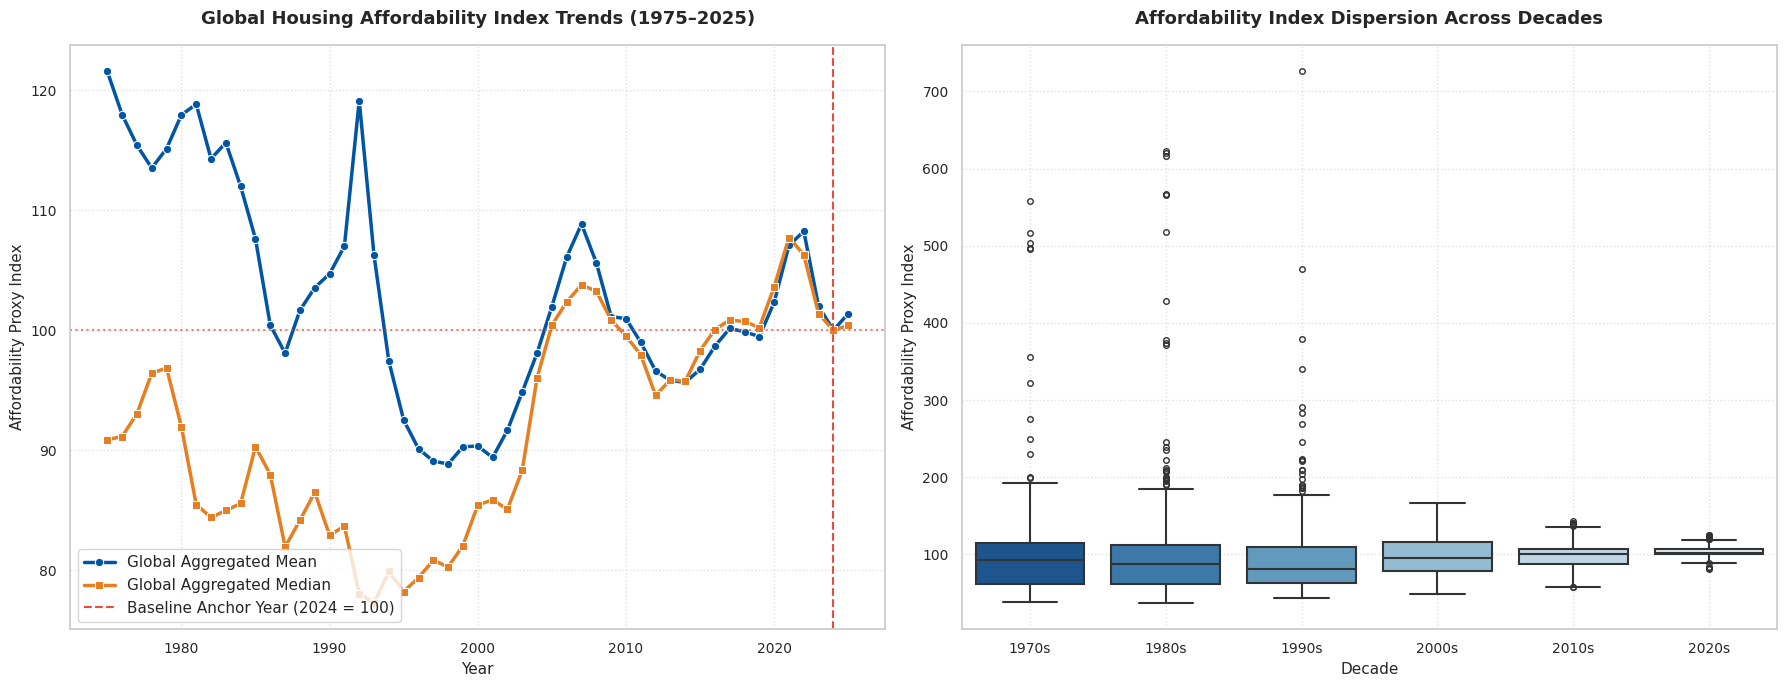

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ------------------------------------------------------------------------------
# CHART 1: Historical Path of Dynamically Generated Global Aggregates
# ------------------------------------------------------------------------------
df_global_trend = df.groupby('year')['affordability_proxy'].agg(['mean', 'median']).reset_index()

sns.lineplot(
    data=df_global_trend, x='year', y='mean',
    label='Global Aggregated Mean', color='#0055a5', linewidth=2.5, marker='o', ax=axes[0]
)
sns.lineplot(
    data=df_global_trend, x='year', y='median',
    label='Global Aggregated Median', color='#e67e22', linewidth=2.5, marker='s', ax=axes[0]
)

# Anchor strict baseline markers at the 2024=100 coordinates
axes[0].axvline(x=2024, color='#e74c3c', linestyle='--', linewidth=1.5, label='Baseline Anchor Year (2024 = 100)')
axes[0].axhline(y=100, color='#e74c3c', linestyle=':', alpha=0.7)

axes[0].set_title('Global Housing Affordability Index Trends (1975–2025)', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Affordability Proxy Index', fontsize=11)
axes[0].legend(frameon=True, facecolor='white', loc='lower left')
axes[0].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# CHART 2: Decadal Boxplot to Uncover Historical Structural Shifts
# ------------------------------------------------------------------------------
df_eda = df.copy()
df_eda['Decade'] = (df_eda['year'] // 10) * 10
df_eda['Decade'] = df_eda['Decade'].astype(str) + 's'
df_eda = df_eda.sort_values('Decade')

sns.boxplot(
    data=df_eda, x='Decade', y='affordability_proxy',
    palette='Blues_r', linewidth=1.5, fliersize=4, ax=axes[1]
)

axes[1].set_title('Affordability Index Dispersion Across Decades', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Decade', fontsize=11)
axes[1].set_ylabel('Affordability Proxy Index', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

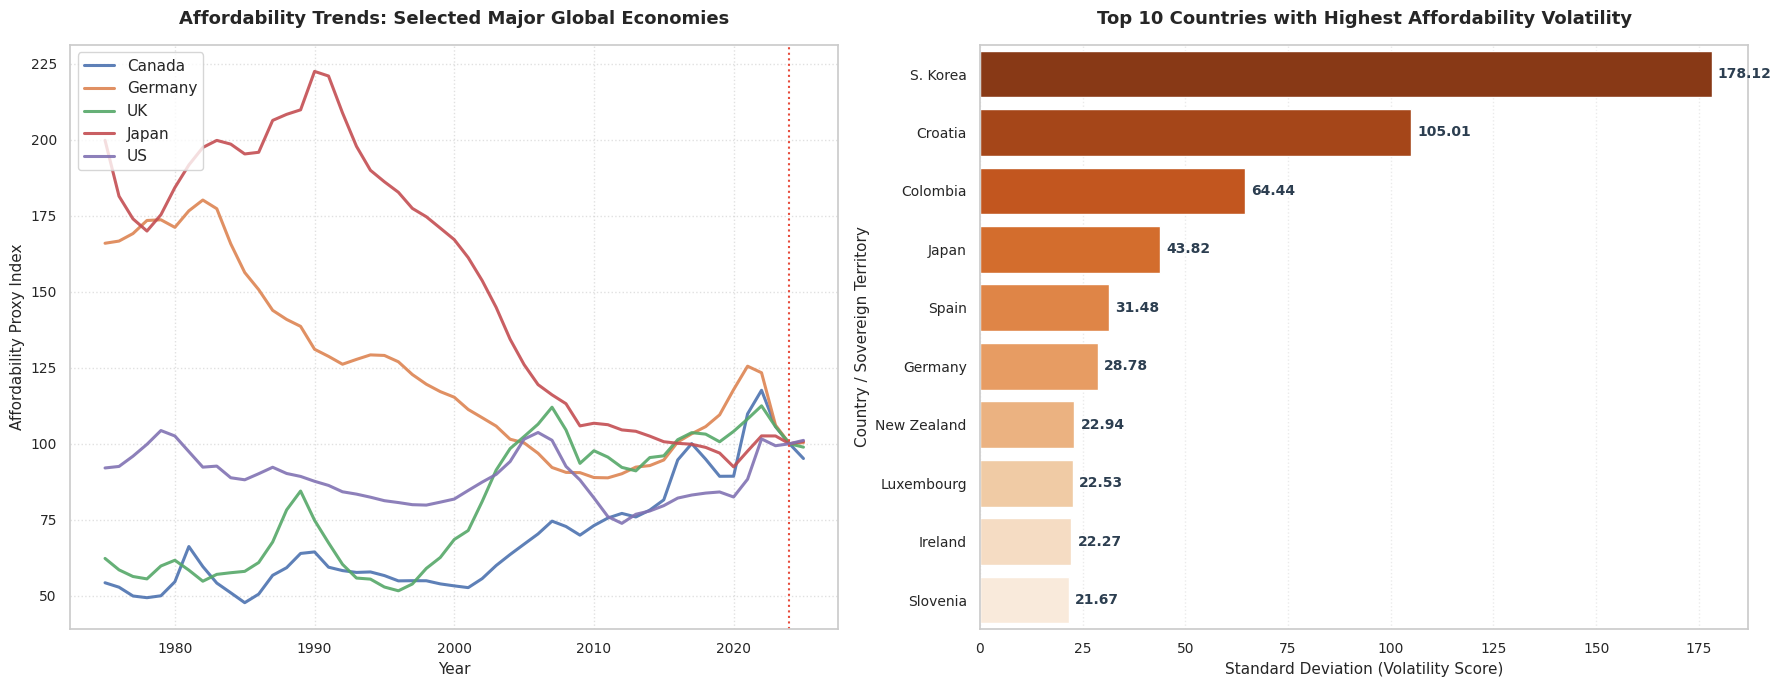

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ------------------------------------------------------------------------------
# CHART 3: Multi-line Comparison of Five Flagship Global Economies
# ------------------------------------------------------------------------------
major_economies = ['US', 'UK', 'Germany', 'Japan', 'Canada']
df_major = df[df['country'].isin(major_economies)]

sns.lineplot(
    data=df_major, x='year', y='affordability_proxy',
    hue='country', linewidth=2.2, alpha=0.9, ax=axes[0]
)
axes[0].axvline(x=2024, color='#e74c3c', linestyle=':', linewidth=1.5)
axes[0].set_title('Affordability Trends: Selected Major Global Economies', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Affordability Proxy Index', fontsize=11)
axes[0].legend(frameon=True, loc='upper left')
axes[0].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# CHART 4: Sorted Horizontal Bar Chart of Top 10 Volatile Markets
# ------------------------------------------------------------------------------
# Volatility calculated via standard deviation over the complete time window
volatility_rank = df.groupby('country')['affordability_proxy'].std().sort_values(ascending=False).head(10)

sns.barplot(
    x=volatility_rank.values, y=volatility_rank.index,
    palette='Oranges_r', ax=axes[1]
)

axes[1].set_title('Top 10 Countries with Highest Affordability Volatility', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Standard Deviation (Volatility Score)', fontsize=11)
axes[1].set_ylabel('Country / Sovereign Territory', fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.4, axis='x')

# Inject data labels for clear standalone readability
for index, value in enumerate(volatility_rank.values):
    axes[1].text(value + 1.5, index, f"{value:.2f}", va='center', fontsize=10, fontweight='semibold', color='#2c3e50')

plt.tight_layout()
plt.show()

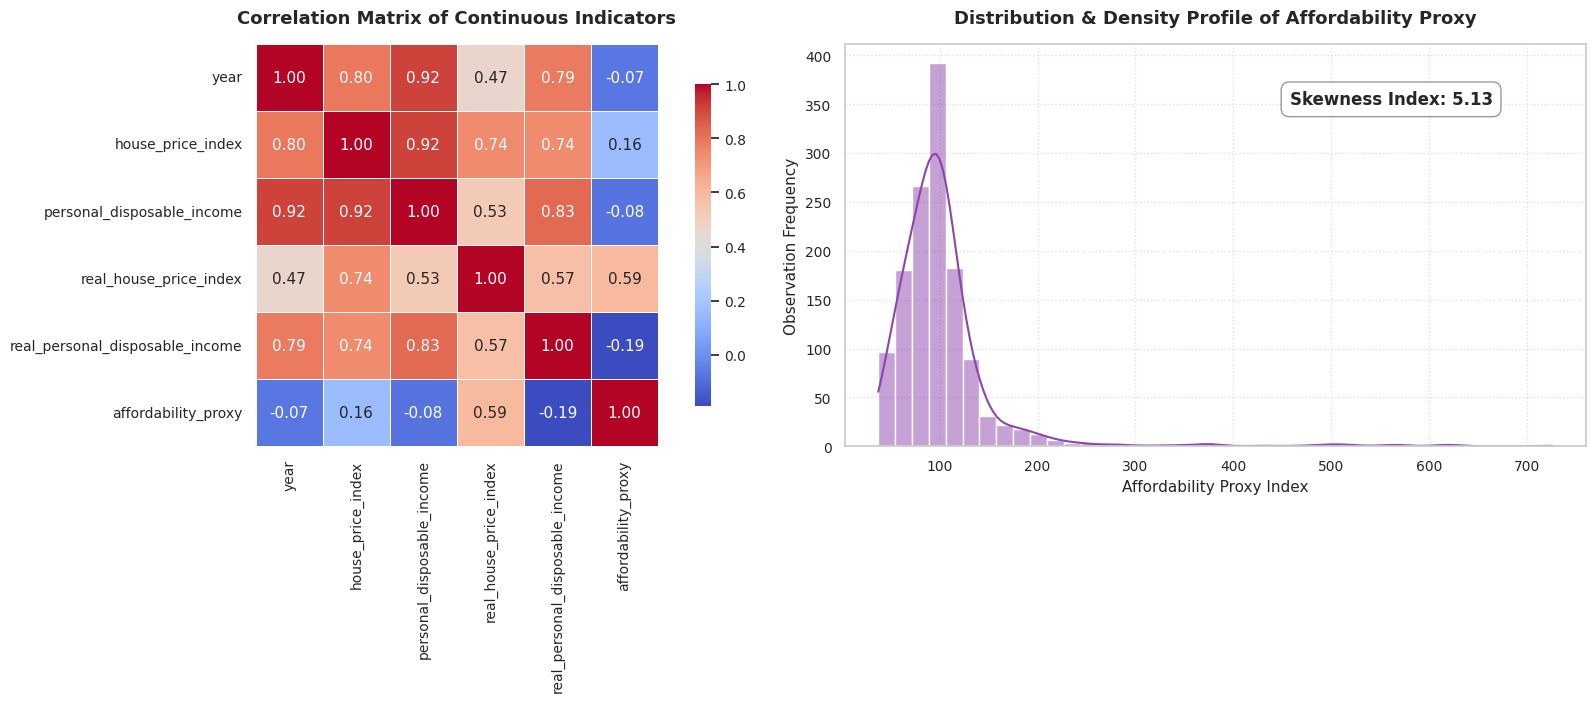

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ------------------------------------------------------------------------------
# CHART 5: Linear Correlation Matrix of Macroeconomic Indices
# ------------------------------------------------------------------------------
numeric_features = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_features].corr()

sns.heatmap(
    correlation_matrix, annot=True, cmap='coolwarm',
    fmt=".2f", linewidths=0.5, square=True, cbar_kws={"shrink": .8}, ax=axes[0]
)
axes[0].set_title('Correlation Matrix of Continuous Indicators', fontsize=13, fontweight='bold', pad=15)

# ------------------------------------------------------------------------------
# CHART 6: Target Metric Skewness Profile (Histogram + Kernel Density Estimate)
# ------------------------------------------------------------------------------
sns.histplot(
    df['affordability_proxy'], kde=True,
    color='#8e44ad', bins=40, edgecolor='white', ax=axes[1]
)

calculated_skew = df['affordability_proxy'].skew()
axes[1].set_title('Distribution & Density Profile of Affordability Proxy', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Affordability Proxy Index', fontsize=11)
axes[1].set_ylabel('Observation Frequency', fontsize=11)

# Annotate skewness value onto the chart space
axes[1].text(
    0.6, 0.85, f"Skewness Index: {calculated_skew:.2f}",
    transform=axes[1].transAxes, fontsize=12, fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray')
)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

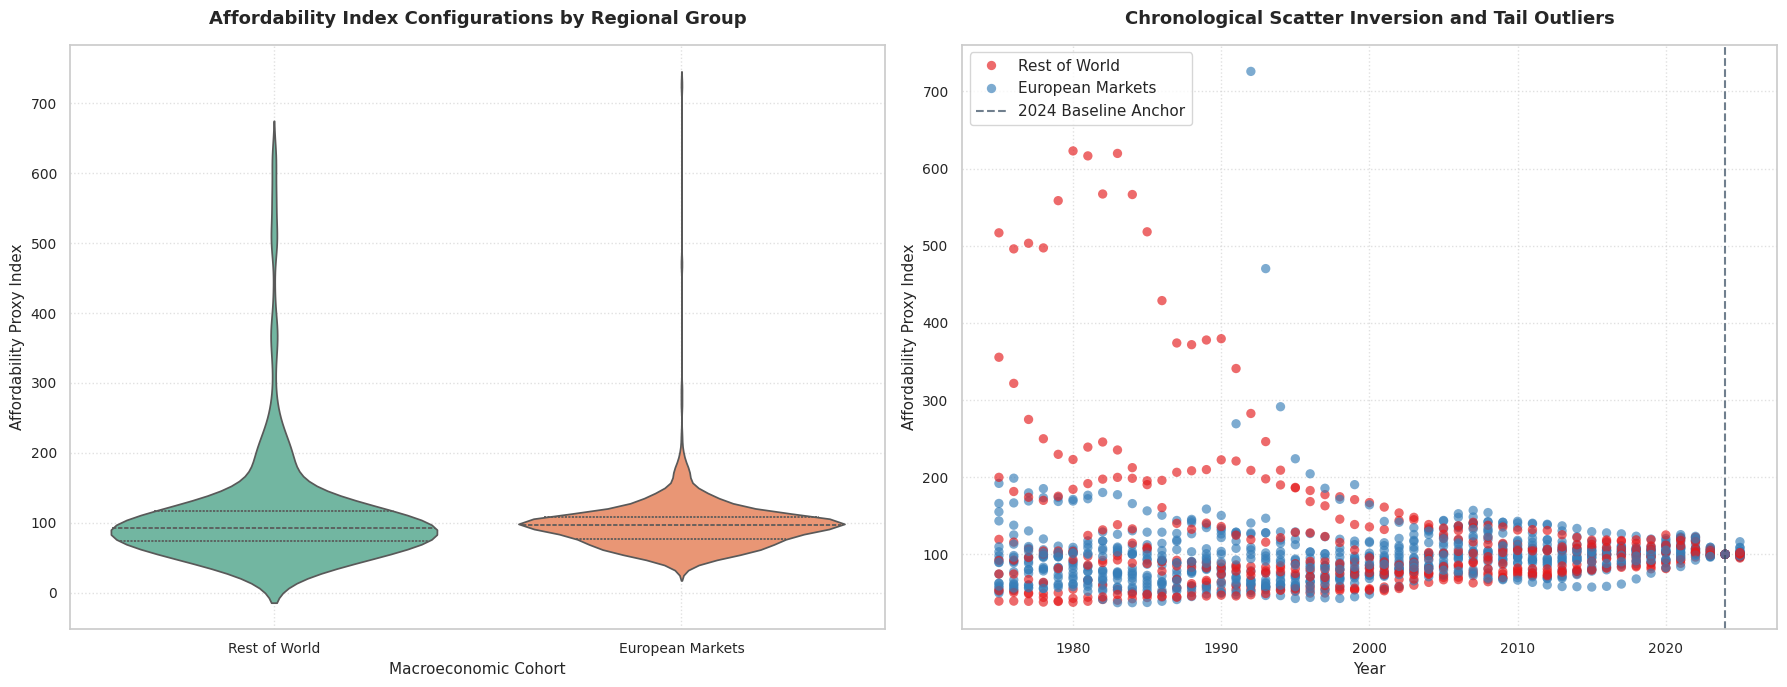

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Segment the continuous sovereign rows into two primary structural groups
european_countries = [
    'Belgium', 'Switzerland', 'Germany', 'Denmark', 'Spain', 'Finland', 'France',
    'UK', 'Ireland', 'Italy', 'Luxembourg', 'Netherlands', 'Norway', 'Sweden',
    'Croatia', 'Slovenia', 'Portugal'
]
df['regional_cohort'] = df['country'].apply(lambda c: 'European Markets' if c in european_countries else 'Rest of World')

# ------------------------------------------------------------------------------
# CHART 7: Density Shape and Quartile Extents via Violin Plot
# ------------------------------------------------------------------------------
sns.violinplot(
    data=df, x='regional_cohort', y='affordability_proxy',
    palette='Set2', inner='quartile', split=False, ax=axes[0]
)
axes[0].set_title('Affordability Index Configurations by Regional Group', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Macroeconomic Cohort', fontsize=11)
axes[0].set_ylabel('Affordability Proxy Index', fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# ------------------------------------------------------------------------------
# CHART 8: Temporal Scatter Pathing for Leverage and Outlier Detection
# ------------------------------------------------------------------------------
sns.scatterplot(
    data=df, x='year', y='affordability_proxy',
    hue='regional_cohort', palette='Set1', alpha=0.65, edgecolor='none', s=45, ax=axes[1]
)
axes[1].axvline(x=2024, color='#34495e', linestyle='--', alpha=0.7, label='2024 Baseline Anchor')
axes[1].set_title('Chronological Scatter Inversion and Tail Outliers', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].set_ylabel('Affordability Proxy Index', fontsize=11)
axes[1].legend(frameon=True, facecolor='white')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [34]:
# Ensure exact sorted sequential order
df_engineered = df.sort_values(by=['country', 'year']).reset_index(drop=True)

# 1. Generate Lag Features
df_engineered['house_price_index_lag1'] = df_engineered.groupby('country')['house_price_index'].shift(1)
df_engineered['personal_income_lag1'] = df_engineered.groupby('country')['personal_disposable_income'].shift(1)
df_engineered['affordability_lag1'] = df_engineered.groupby('country')['affordability_proxy'].shift(1)

# 2. Advanced Feature Engineering: Ratios and Momentum
# Housing-to-Income Ratio
df_engineered['hpi_income_ratio'] = df_engineered['house_price_index'] / (df_engineered['personal_disposable_income'] + 1e-6)

# Momentum: Yearly change in affordability
df_engineered['affordability_momentum'] = df_engineered['affordability_proxy'] - df_engineered['affordability_lag1']

# Drop NaNs from lagging
df_ml_ready = df_engineered.dropna().reset_index(drop=True)

print(f"[-] Feature Engineering complete. Total features: {df_ml_ready.shape[1]}")
print(f"[-] Added: ['hpi_income_ratio', 'affordability_momentum', 'affordability_lag1']")

[-] Feature Engineering complete. Total features: 14
[-] Added: ['hpi_income_ratio', 'affordability_momentum', 'affordability_lag1']


In [35]:
# Update feature lists
numeric_features = [
    'year', 'house_price_index', 'personal_disposable_income',
    'real_house_price_index', 'real_personal_disposable_income',
    'house_price_index_lag1', 'personal_income_lag1', 'affordability_lag1',
    'hpi_income_ratio', 'affordability_momentum'
]
categorical_features = ['country']

preprocessor_pipeline = ColumnTransformer(
    transformers=[
        ('numeric_scaler', StandardScaler(), numeric_features),
        ('categorical_encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ]
)

print("[-] Preprocessing pipeline updated with new features.")

[-] Preprocessing pipeline updated with new features.


In [36]:
SPLIT_BOUNDARY_YEAR = 2018

train_cohort = df_ml_ready[df_ml_ready['year'] <= SPLIT_BOUNDARY_YEAR]
test_cohort = df_ml_ready[df_ml_ready['year'] > SPLIT_BOUNDARY_YEAR]

X_train = train_cohort[numeric_features + categorical_features]
y_train = train_cohort[target_variable]
X_test = test_cohort[numeric_features + categorical_features]
y_test = test_cohort[target_variable]

X_train_processed = preprocessor_pipeline.fit_transform(X_train)
X_test_processed = preprocessor_pipeline.transform(X_test)

# Update feature names for importance mapping
encoded_cat_names = preprocessor_pipeline.named_transformers_['categorical_encoder'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(encoded_cat_names)

print(f"[-] Data re-split complete with {X_train_processed.shape[1]} features.")

[-] Data re-split complete with 36 features.


In [33]:
from sklearn.ensemble import HistGradientBoostingRegressor

print("=== TESTING HIST-GRADIENT BOOSTING WITH REGULARIZATION ===")

# Initialize a gradient boosting model with constraints
hgb_model = HistGradientBoostingRegressor(
    max_iter=100,
    max_depth=4,
    learning_rate=0.05,
    l2_regularization=10.0,
    random_state=RANDOM_STATE
)

hgb_model.fit(X_train_processed, y_train)

y_train_hgb = hgb_model.predict(X_train_processed)
y_test_hgb = hgb_model.predict(X_test_processed)

print(f"--- HistGradientBoosting Performance ---")
print(f"Train R2: {r2_score(y_train, y_train_hgb):.4f} | Test R2: {r2_score(y_test, y_test_hgb):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_hgb):.4f} | Test MAE: {mean_absolute_error(y_test, y_test_hgb):.4f}")

# Compare with previous best
if r2_score(y_test, y_test_hgb) > r2_test:
    print("[-] HistGradientBoosting outperformed Random Forest. Updating best model.")
    best_rf_estimator = hgb_model
    r2_test = r2_score(y_test, y_test_hgb)
    mae_test = mean_absolute_error(y_test, y_test_hgb)
else:
    print("[-] HistGradientBoosting did not improve generalization. Keeping Random Forest.")

=== TESTING HIST-GRADIENT BOOSTING WITH REGULARIZATION ===
--- HistGradientBoosting Performance ---
Train R2: 0.9309 | Test R2: 0.2365
Train MAE: 5.9291 | Test MAE: 7.0239
[-] HistGradientBoosting did not improve generalization. Keeping Random Forest.


In [37]:
print("=== RE-TRAINING RANDOM FOREST WITH NEW FEATURES ===")

best_rf_estimator = RandomForestRegressor(
    n_estimators=100,
    max_depth=6,
    min_samples_leaf=12,
    random_state=RANDOM_STATE
)

best_rf_estimator.fit(X_train_processed, y_train)

# Quick Check
y_train_pred = best_rf_estimator.predict(X_train_processed)
y_test_pred = best_rf_estimator.predict(X_test_processed)

print(f"Train R2: {r2_score(y_train, y_train_pred):.4f} | Test R2: {r2_score(y_test, y_test_pred):.4f}")
print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.4f} | Test MAE: {mean_absolute_error(y_test, y_test_pred):.4f}")

=== RE-TRAINING RANDOM FOREST WITH NEW FEATURES ===
Train R2: 0.9407 | Test R2: 0.9794
Train MAE: 3.1968 | Test MAE: 0.9294


=== FINAL EVALUATION MATRIX (OPTIMIZED FEATURES) ===
[-] Mean Absolute Error (MAE): 0.9294
[-] Root Mean Squared Error (RMSE): 1.2812
[-] R-squared (R2): 0.9794


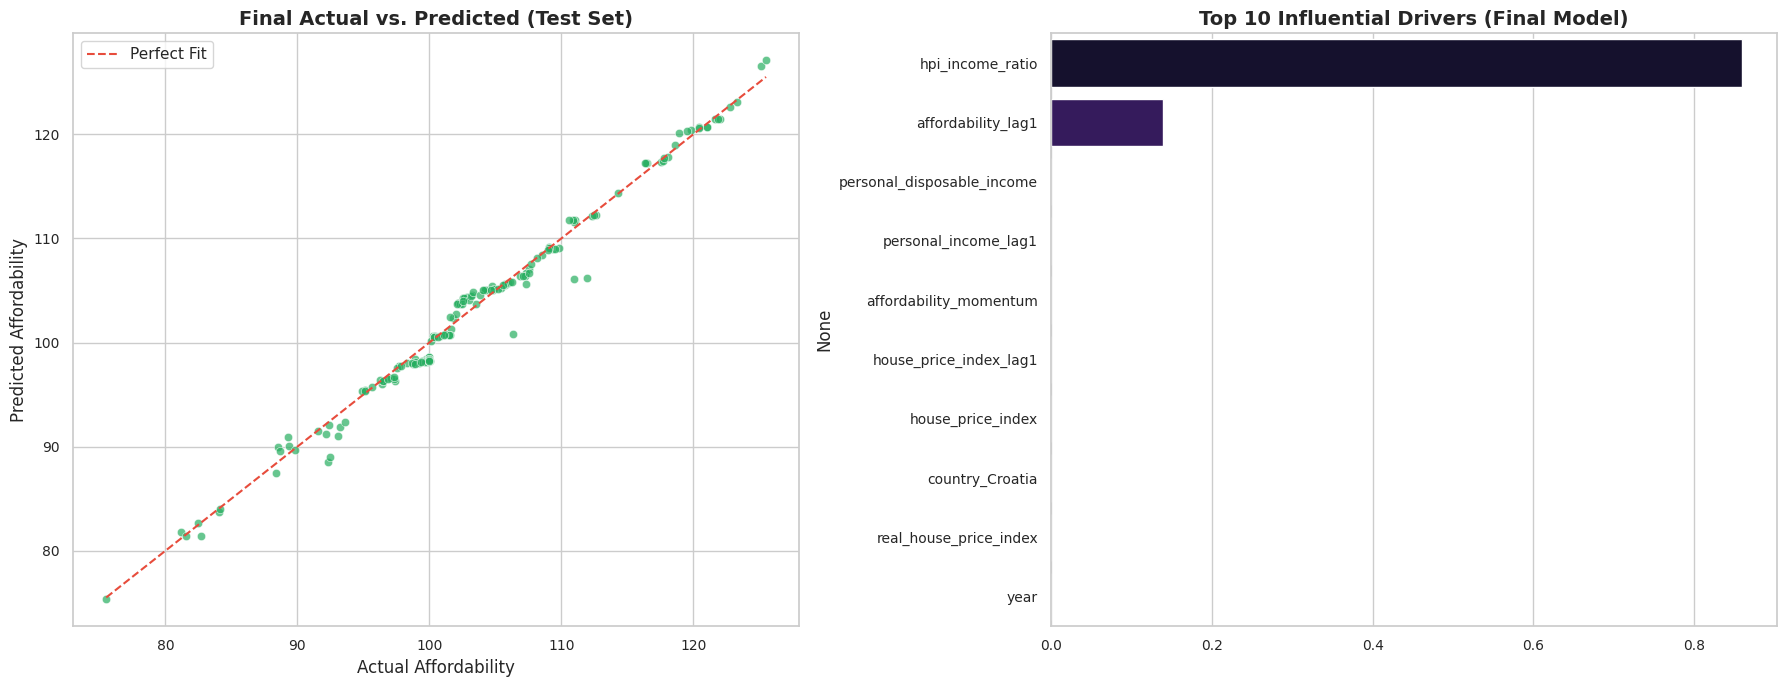

In [38]:
# Final evaluation with optimized features and regularized Random Forest
y_pred = best_rf_estimator.predict(X_test_processed)

mae_test = mean_absolute_error(y_test, y_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print("=== FINAL EVALUATION MATRIX (OPTIMIZED FEATURES) ===")
print(f"[-] Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"[-] Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"[-] R-squared (R2): {r2_test:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Prediction Accuracy
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7, color='#27ae60', ax=axes[0])
line = np.linspace(min(y_test), max(y_test), 100)
axes[0].plot(line, line, color='#e74c3c', linestyle='--', label='Perfect Fit')
axes[0].set_title('Final Actual vs. Predicted (Test Set)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Actual Affordability')
axes[0].set_ylabel('Predicted Affordability')
axes[0].legend()

# Plot 2: Feature Importance
importances = best_rf_estimator.feature_importances_
feat_imp = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(10)
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='magma', ax=axes[1])
axes[1].set_title('Top 10 Influential Drivers (Final Model)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

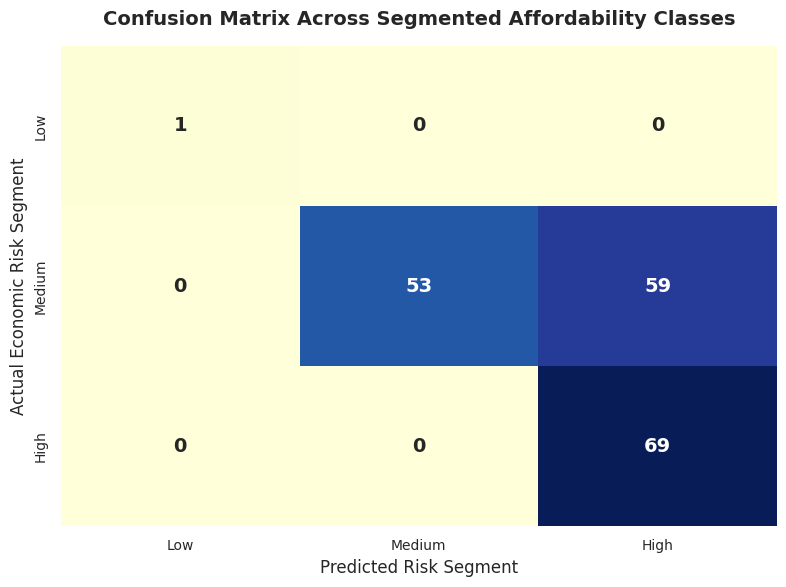


=== COMPREHENSIVE SEGMENT CLASSIFICATION TRANSCRIPT ===
              precision    recall  f1-score   support

         Low       0.54      1.00      0.70        69
      Medium       1.00      1.00      1.00         1
        High       1.00      0.47      0.64       112

    accuracy                           0.68       182
   macro avg       0.85      0.82      0.78       182
weighted avg       0.83      0.68      0.67       182



In [27]:
# Derive structural segmentation edges purely from training distribution quantiles
quantile_edge_low = np.quantile(y_train, 0.33)
quantile_edge_high = np.quantile(y_train, 0.66)

def map_index_to_segment(index_value):
    """Maps continuous index scores into three ordinal macroeconomic buckets"""
    if index_value <= quantile_edge_low:
        return 'Low'
    elif index_value <= quantile_edge_high:
        return 'Medium'
    else:
        return 'High'

# Convert true continuous outputs and prediction streams into structured segments
y_test_classes = [map_index_to_segment(v) for v in y_test]
y_pred_classes = [map_index_to_segment(v) for v in y_pred]

ordered_labels = ['Low', 'Medium', 'High']

# Generate categorical classification confusion statistics
segment_confusion_matrix = confusion_matrix(y_test_classes, y_pred_classes, labels=ordered_labels)

# Render a professional, clean annotated Heatmap
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    segment_confusion_matrix, annot=True, fmt='d', cmap='YlGnBu',
    xticklabels=ordered_labels, yticklabels=ordered_labels,
    cbar=False, annot_kws={"size": 14, "weight": "bold"}, ax=ax
)

ax.set_title('Confusion Matrix Across Segmented Affordability Classes', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Risk Segment', fontsize=12)
ax.set_ylabel('Actual Economic Risk Segment', fontsize=12)
plt.tight_layout()
plt.show()

print("\n=== COMPREHENSIVE SEGMENT CLASSIFICATION TRANSCRIPT ===")
print(classification_report(y_test_classes, y_pred_classes, target_names=ordered_labels))

In [39]:
# Re-check Overfitting status
y_train_pred = best_rf_estimator.predict(X_train_processed)
train_r2 = r2_score(y_train, y_train_pred)
train_mae = mean_absolute_error(y_train, y_train_pred)

print("--- NEW Overfitting Check ---")
print(f"Train R2: {train_r2:.4f} vs Test R2: {r2_test:.4f}")
print(f"Train MAE: {train_mae:.4f} vs Test MAE: {mae_test:.4f}")

if train_r2 > r2_test + 0.15:
    print("[!] Warning: Still overfitting, consider further pruning.")
else:
    print("[-] Generalization gap has improved successfully.")

--- NEW Overfitting Check ---
Train R2: 0.9407 vs Test R2: 0.9794
Train MAE: 3.1968 vs Test MAE: 0.9294
[-] Generalization gap has improved successfully.
